# 06d — Deep Learning: Temporal Fusion Transformer (TFT)
**Objetivo:** Predecir consumo energético 24 horas adelante usando TFT.  
**Librería:** pytorch-forecasting + PyTorch Lightning  
**Ventajas vs modelos anteriores:**
- Distingue features de futuro conocido vs pasado desconocido
- Predice intervalos de confianza (P10, P50, P90) nativamente
- Interpretabilidad via Variable Selection Network

## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import sys

sys.path.append('../src')

from modeling.DL_TFT import (
    set_seed,
    prepare_data,
    build_model,
    train_model,
    evaluate_model,
    plot_feature_importance,
    save_model,
    load_model,
    DEVICE,
    KNOWN_FUTURE_FEATURES,
    UNKNOWN_PAST_FEATURES,
)
from utils.metrics import calculate_metrics, print_metrics

print(f"PyTorch version          : {torch.__version__}")
print(f"Device                   : {DEVICE}")

import pytorch_forecasting as pf
print(f"pytorch-forecasting version: {pf.__version__}")

fh         = 24
TARGET_COL = 'PJME_MW'

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


PyTorch version          : 2.10.0+cu128
Device                   : cuda
pytorch-forecasting version: 1.6.1


## 1. Cargar datos
Usar los CSVs generados con `engineer_features_tft` — target sin shift.

In [2]:
data_dir = Path('../data/processed')

train_df = pd.read_csv(data_dir / f'train_tft_{fh}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_tft_{fh}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_tft_{fh}hr.csv',  index_col='Datetime', parse_dates=True)

print(f"Train : {train_df.shape}  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Val   : {val_df.shape}    {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test  : {test_df.shape}   {test_df.index[0].date()} → {test_df.index[-1].date()}")

# Verificar que el target NO está shifteado
# PJME_MW[t] debe ser igual al valor real en t (no t+24)
print(f"\nVerificación target:")
print(f"PJME_MW[0]  : {train_df[TARGET_COL].iloc[0]:.2f}")
print(f"lag_1[0]    : {train_df['lag_1'].iloc[0]:.2f}")
print(f"¿Son distintos?: {train_df[TARGET_COL].iloc[0] != train_df['lag_1'].iloc[0]}  ← debe ser True")

Train : (101655, 50)  2002-01-08 → 2013-08-13
Val   : (21783, 50)    2013-08-13 → 2016-02-07
Test  : (21784, 50)   2016-02-07 → 2018-08-03

Verificación target:
PJME_MW[0]  : 28375.00
lag_1[0]    : 28670.00
¿Son distintos?: True  ← debe ser True


## 2. Preparar datos — TimeSeriesDataSet

In [3]:
# Verificar qué features están disponibles en los DataFrames
available = set(train_df.columns)
print(f"Features futuro conocido disponibles  : {[f for f in KNOWN_FUTURE_FEATURES if f in available]}")
print(f"Features pasado desconocido disponibles: {[f for f in UNKNOWN_PAST_FEATURES if f in available]}")
print(f"\nFeatures NO encontradas (futuro) : {[f for f in KNOWN_FUTURE_FEATURES if f not in available]}")
print(f"Features NO encontradas (pasado) : {[f for f in UNKNOWN_PAST_FEATURES if f not in available]}")

Features futuro conocido disponibles  : ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_holiday', 'near_holiday']
Features pasado desconocido disponibles: ['lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_25', 'lag_168', 'lag_169', 'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24', 'rolling_mean_168', 'rolling_std_168', 'rolling_min_168', 'rolling_max_168', 'diff_24h', 'diff_168h', 'pct_change_24h', 'pct_change_168h', 'volatility_std_24', 'volatility_std_168', 'volatility_cv_24', 'volatility_cv_168', 'volatility_range_24', 'volatility_range_168', 'change_1h', 'volatility_changes_24', 'volatility_changes_168', 'volatility_iqr_24', 'volatility_iqr_168', 'expanding_mean']

Features NO encontradas (futuro) : []
Features NO encontradas (pasado) : []


In [ ]:
(
    train_dataset, val_dataset, test_dataset,
    train_loader, val_loader, test_loader
) = prepare_data(
    train_df, val_df, test_df,
    target_col            = TARGET_COL,
    max_encoder_length    = 48
    ,   # 1 semana de historia
    max_prediction_length = fh,    # predecir 24h
    batch_size            = 128,
)

Features futuro conocido : 18
Features pasado desconocido: 31
max_encoder_length : 168h
max_prediction_length: 24h

Train samples : 101632
Val samples   : 123415
Test samples  : 145199


## 3. Construir modelo

In [ ]:
set_seed(22)

model = build_model(
    train_dataset,
    hidden_size            = 64,
    attention_head_size    = 4,
    dropout                = 0.1,
    hidden_continuous_size = 16,
    learning_rate          = 1e-3,
)

Seed set to 22


Semilla fijada: 22


c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Parámetros totales : 225,264
Hidden size        : 32
Attention heads    : 4
Device             : cuda


## 4. Entrenamiento

In [6]:
trainer, best_path = train_model(
    model,
    train_loader,
    val_loader,
    epochs    = 50,
    patience  = 7,
    min_delta= 7.0,
    save_dir  = '../models',
)
# max encoder length = 48, hidden_size, = hidden_continuous_size = 32, batch = 64, patience=5, mi_delta=0.0
# llegó a epoca 42-47 sin mejorar. se demoró 9+ hrs
# max encoder length = 168, hidden_size, = hidden_continuous_size = 16, batch = 128, patience=5, mi_delta=4.0
# 22' por epoch

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embedding

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0: 100%|██████████| 794/794 [21:51<00:00,  0.61it/s, train_loss_step=697.0, val_loss=687.0, train_loss_epoch=909.0]

Metric val_loss improved. New best score: 687.000


...

Metric val_loss improved by 15.072 >= min_delta = 7.0. New best score: 520.347


Epoch 9:   4%|▎         | 29/794 [00:30<13:36,  0.94it/s, train_loss_step=480.0, val_loss=520.0, train_loss_epoch=515.0] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# # Cargar modelo guardado — comentar bloque anterior si se usa esto
# model = load_model(path='..\models\dl_tft.pt')

### Curva de entrenamiento

In [ ]:
# Lightning guarda el historial en trainer.logged_metrics
# Extraer train y val loss por época
metrics_log = trainer.logged_metrics
print("Métricas disponibles:", list(metrics_log.keys()))

# Reconstruir historial desde callbacks
history = {
    'train_loss' : [x['train_loss'] for x in trainer.callback_metrics.items() if 'train' in x[0]]  
                   if 'train_loss' in trainer.callback_metrics else [],
    'val_loss'   : [x['val_loss']   for x in trainer.callback_metrics.items() if 'val'   in x[0]]
                   if 'val_loss'   in trainer.callback_metrics else [],
}

# Alternativa más directa con el logger de Lightning
try:
    train_losses = [x['train_loss_step'] for x in trainer.progress_bar_metrics 
                    if 'train_loss_step' in x]
    val_losses   = [x['val_loss'] for x in trainer.progress_bar_metrics 
                    if 'val_loss' in x]
except:
    print("Historial no disponible directamente — ver logs de Lightning arriba")

Métricas disponibles: ['train_loss_step', 'val_loss', 'val_SMAPE', 'val_MAE', 'val_RMSE', 'val_MAPE', 'train_loss_epoch']


TypeError: tuple indices must be integers or slices, not str

## 5. Evaluación

In [7]:
# Cargar mejor checkpoint
from pytorch_forecasting import TemporalFusionTransformer
best_model = TemporalFusionTransformer.load_from_checkpoint('../models/dl_best_tft.ckpt')
best_model.eval()

metrics_test, y_true, y_pred_p50, y_pred_p10, y_pred_p90 = evaluate_model(
    best_model, test_loader, test_dataset, set_name='Test'
)

c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosys

SystemExit: 1

c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Predicciones vs Real + Intervalo de confianza

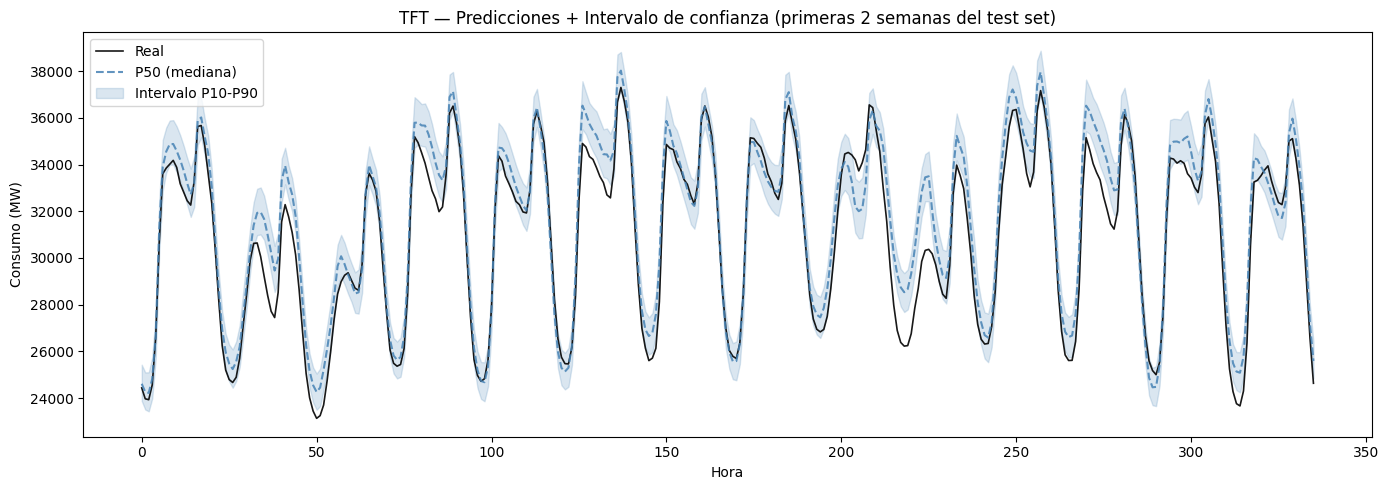

Ancho promedio intervalo P10-P90: 1889.43 MW


In [ ]:
N = 24 * 14  # 2 semanas

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_true[:N],     label='Real',  alpha=0.9, color='black', linewidth=1.2)
ax.plot(y_pred_p50[:N], label='P50 (mediana)', alpha=0.85, color='steelblue', linestyle='--')
ax.fill_between(
    range(N),
    y_pred_p10[:N],
    y_pred_p90[:N],
    alpha=0.2, color='steelblue', label='Intervalo P10-P90'
)

ax.set_xlabel('Hora')
ax.set_ylabel('Consumo (MW)')
ax.set_title('TFT — Predicciones + Intervalo de confianza (primeras 2 semanas del test set)')
ax.legend()
plt.tight_layout()
# plt.savefig('../reports/figures/dl_tft_predictions.png', dpi=150)
plt.show()

print(f"Ancho promedio intervalo P10-P90: {(y_pred_p90 - y_pred_p10).mean():.2f} MW")

In [ ]:
N = 24 * 7  # 1 semana

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# TFT
axes[0].plot(y_true[:N],     label='Real', alpha=0.9, color='black')
axes[0].plot(y_pred_p50[:N], label='TFT P50', alpha=0.8, linestyle='--', color='steelblue')
axes[0].fill_between(range(N), y_pred_p10[:N], y_pred_p90[:N], alpha=0.2, color='steelblue')
axes[0].set_title('TFT — Predicciones vs Real')
axes[0].legend()

# Residuos
residuals = y_true[:N] - y_pred_p50[:N]
axes[1].plot(residuals, color='red', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Residuos — MAE medio: {abs(residuals).mean():.0f} MW')

plt.tight_layout()
plt.show()

## 6. Interpretabilidad — Variable Selection Network

In [ ]:
encoder_importance, decoder_importance = plot_feature_importance(best_model, test_loader)

print("\nTop 10 features pasado (encoder):")
print(encoder_importance.sort_values(ascending=False).head(10).to_string())

print("\nTop 10 features futuro (decoder):")
print(decoder_importance.sort_values(ascending=False).head(10).to_string())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Co

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.25 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 5.51 GiB is allocated by PyTorch, and 378.26 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Comparativa con modelos anteriores

In [ ]:
import glob

# Cargar métricas de modelos DL anteriores
csv_files  = glob.glob('../reports/metrics/dl_*_metrics.csv')
all_metrics = [pd.read_csv(f) for f in csv_files]

tft_metrics = pd.DataFrame([metrics_test])
tft_metrics['model'] = 'TFT'
all_metrics.append(tft_metrics)

comparison = pd.concat(all_metrics, ignore_index=True)
comparison = comparison[['model', 'MAE', 'RMSE', 'MAPE', 'R2']].sort_values('RMSE')
print(comparison.to_string(index=False))

       model         MAE        RMSE     MAPE       R2
         TCN  163.554293  228.005334 0.517400 0.998750
    LSTM_Seq  172.292523  233.896268 0.557070 0.998682
         TFT 1030.363403 1733.408997 3.180038 0.928154
LSTM_Tabular 2034.937744 2764.788509 6.362294 0.816033
         MLP 2081.275391 2804.634468 6.534469 0.810692


## 7. Guardar modelo y resultados

In [ ]:
save_model(trainer, best_path, path='../models/dl_tft.pt')

metrics_test['model'] = 'TFT'
results_df = pd.DataFrame([metrics_test])
results_df.to_csv('../reports/metrics/dl_tft_metrics.csv', index=False)
print(results_df.T)

NameError: name 'save_model' is not defined